In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Lock all random seeds for reproducibility
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

print("Libraries imported and random seeds locked.")

Libraries imported and random seeds locked.


In [2]:
# Cell 2: Load Data and Strict Preprocessing
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. LOAD THE DATA (Updated with correct folder paths)
train_file = "data/KDDTrain+.txt"
test_file = "data/KDDTest+.txt"

# NSL-KDD datasets usually don't have header rows, so we define the 43 columns:
col_names = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty"]

# Load the data into the variables
train_df = pd.read_csv(train_file, header=None, names=col_names)
test_df = pd.read_csv(test_file, header=None, names=col_names)

# 2. DEFINE PREPROCESSING FUNCTION
def preprocess_network_data(train_data, test_data, target_col='label'):
    # Separate Features and Targets
    X_train = train_data.drop(columns=[target_col])
    # Convert labels to 0 (normal) and 1 (attack)
    y_train = train_data[target_col].apply(lambda x: 0 if x == 'normal' else 1)
    
    X_test = test_data.drop(columns=[target_col])
    y_test = test_data[target_col].apply(lambda x: 0 if x == 'normal' else 1)

    # Drop 'difficulty' column as it is not meant for training
    if 'difficulty' in X_train.columns:
        X_train = X_train.drop('difficulty', axis=1)
        X_test = X_test.drop('difficulty', axis=1)

    # Handle Categorical Columns (One-Hot Encoding)
    categorical_cols = X_train.select_dtypes(include=['object']).columns
    X_train = pd.get_dummies(X_train, columns=categorical_cols)
    X_test = pd.get_dummies(X_test, columns=categorical_cols)
    
    # Align columns to ensure train and test sets have the exact same features
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    # Scale the Data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train.values, y_test.values

import pandas as pd
import numpy as np

def apply_feature_engineering(df):
    # 1. Byte Ratio (Are we sending way more than we receive?)
    # We add 1 to the denominator to avoid division by zero
    df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
    
    # 2. Connection Intensity (How much data is moving per second?)
    df['data_intensity'] = (df['src_bytes'] + df['dst_bytes']) / (df['duration'] + 0.01)
    
    # 3. Error Rate Aggregation (Combining different error signals)
    # This creates a 'Global Error Score'
    error_cols = ['serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate']
    df['combined_error_score'] = df[error_cols].sum(axis=1)
    
    # 4. Service-Specific Anomaly (Grouping common services)
    # Helps the model identify attacks that target specific protocols
    df['is_http'] = df['service'].apply(lambda x: 1 if x == 'http' else 0)
    df['is_dns'] = df['service'].apply(lambda x: 1 if x == 'domain_u' else 0)
    
    # 5. Login Suspicion (Combining login failures with guest status)
    df['login_risk_score'] = df['num_failed_logins'] + df['is_guest_login']
    
    # 6. Host-Based Velocity (How fast are connections hitting the same host?)
    df['host_speed'] = df['count'] / (df['srv_count'] + 1)
    
    return df

# Apply the engineering to both DataFrames
print("Applying Feature Engineering...")
train_df = apply_feature_engineering(train_df)
test_df = apply_feature_engineering(test_df)

print(f"New Feature Count: {train_df.shape[1]}")

# 3. EXECUTE PREPROCESSING
X_train_clean, X_test_clean, y_train, y_test = preprocess_network_data(train_df, test_df)

print(f"Training shape: {X_train_clean.shape}, Testing shape: {X_test_clean.shape}")

Applying Feature Engineering...
New Feature Count: 50
Training shape: (125973, 129), Testing shape: (22544, 129)


In [3]:
# Cell 3: Unsupervised Feature Extraction (The Autoencoder)
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Isolate Normal traffic for Autoencoder training
# y_train == 0 represents normal traffic based on our preprocessing
X_train_normal = X_train_clean[y_train == 0]
input_dim = X_train_clean.shape[1]

# 2. Build a deep bottleneck architecture
autoencoder = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'), # Latent space bottleneck
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')

# 3. Train the Autoencoder strictly on normal traffic
print("Training Autoencoder on normal traffic...")
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=15, 
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# 4. Extract Reconstruction Error (MSE) to use as our new feature
print("\nGenerating anomaly scores (MSE)...")
train_reconstructions = autoencoder.predict(X_train_clean)
test_reconstructions = autoencoder.predict(X_test_clean)

train_mse = np.mean(np.power(X_train_clean - train_reconstructions, 2), axis=1).reshape(-1, 1)
test_mse = np.mean(np.power(X_test_clean - test_reconstructions, 2), axis=1).reshape(-1, 1)

# 5. Append MSE to the original datasets
X_train_hybrid = np.hstack((X_train_clean, train_mse))
X_test_hybrid = np.hstack((X_test_clean, test_mse))

print(f"\nHybrid Training shape: {X_train_hybrid.shape}")
print(f"Hybrid Testing shape: {X_test_hybrid.shape}")

Training Autoencoder on normal traffic...
Epoch 1/15


/Users/garvitkumar/Desktop/pbl/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-16 02:08:09.597263: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attribut

In [ ]:
# MISSING CELL: Deep Latent Feature Extraction
from tensorflow.keras.models import Model
import numpy as np
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

print("Extracting Deep Latent Features...")

# 1. Automatically find the bottleneck layer
layer_units = [l.units for l in autoencoder.layers if hasattr(l, 'units')]
min_units = min(layer_units[:-1])
bottleneck_idx = [i for i, l in enumerate(autoencoder.layers) if hasattr(l, 'units') and l.units == min_units][0]

# 2. Create the encoder model using the internal Functional API
encoder_only = Model(inputs=autoencoder.inputs, outputs=autoencoder.layers[bottleneck_idx].output)

# 3. Generate Latent Features
latent_train = encoder_only.predict(X_train_clean)
latent_test = encoder_only.predict(X_test_clean)

# 4. Combine Original Features + MSE + Latent Features
X_train_super = np.hstack((X_train_clean, train_mse, latent_train))
X_test_super = np.hstack((X_test_clean, test_mse, latent_test))

print(f"Super-Enriched Feature Count: {X_train_super.shape[1]}")

# 5. Re-balance using SMOTE-Tomek
print("\nRe-balancing Super-Enriched Data...")
smt_super = SMOTETomek(random_state=42)
X_res_super, y_res_super = smt_super.fit_resample(X_train_super, y_train)

# 6. Final XGBoost Training
print("\nTraining Super-Hybrid XGBoost...")
xgb_super = XGBClassifier(
    n_estimators=600,
    learning_rate=0.02,
    max_depth=9,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    eval_metric='logloss'
)

xgb_super.fit(X_res_super, y_res_super)
print("Super-Hybrid XGBoost trained successfully!")

Extracting Deep Latent Features...
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 1s 229us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 250us/step
Super-Enriched Feature Count: 146

Re-balancing Super-Enriched Data...

Training Super-Hybrid XGBoost...
Super-Hybrid XGBoost trained successfully!


In [ ]:
# Cell 5: Final Zero-Leakage Ensemble Evaluation
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Executing Final Decision-Level Ensemble...")

# 1. Get hard predictions from the Super-Hybrid XGBoost
# We explicitly generate this here so the notebook is fully self-contained
y_pred_xgb = xgb_super.predict(X_test_super)

# 2. Mathematically define the Autoencoder Anomaly Threshold
# We set the threshold at the 90th percentile of NORMAL training traffic.
# This means we use the statistical distribution of normal traffic to catch zero-days.
normal_train_mse = train_mse[y_train == 0]
final_thresh = np.percentile(normal_train_mse, 90.0)
print(f"Calculated Anomaly Threshold (90th Percentile): {final_thresh:.4f}")

# 3. Get Autoencoder Anomaly predictions for the Test Set
final_ae_preds = (test_mse > final_thresh).astype(int).flatten()

# 4. Apply the Logical OR (The Safety Net)
# If XGBoost is sure it's an attack OR the AE says it looks weird, flag it!
honest_final_preds = np.logical_or(y_pred_xgb, final_ae_preds).astype(int)

# 5. Display Final Metrics
print("\n--- ULTIMATE HYBRID FRAMEWORK METRICS ---")
print(f"Accuracy: {accuracy_score(y_test, honest_final_preds) * 100:.2f}%\n")
print(classification_report(y_test, honest_final_preds, target_names=['Normal (0)', 'Attack (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, honest_final_preds))

Executing Final Decision-Level Ensemble...
Calculated Anomaly Threshold (90th Percentile): 0.0729

--- ULTIMATE HYBRID FRAMEWORK METRICS ---
Accuracy: 90.80%

              precision    recall  f1-score   support

  Normal (0)       0.90      0.88      0.89      9711
  Attack (1)       0.91      0.93      0.92     12833

    accuracy                           0.91     22544
   macro avg       0.91      0.90      0.91     22544
weighted avg       0.91      0.91      0.91     22544

Confusion Matrix:
[[ 8566  1145]
 [  929 11904]]


Generating Feature Importance Plot...


/var/folders/r9/rk01h0t149ggdbp0z71nf0t80000gn/T/ipykernel_89327/3981866540.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:15]], y=[all_feature_names[i] for i in indices[:15]], palette='magma')


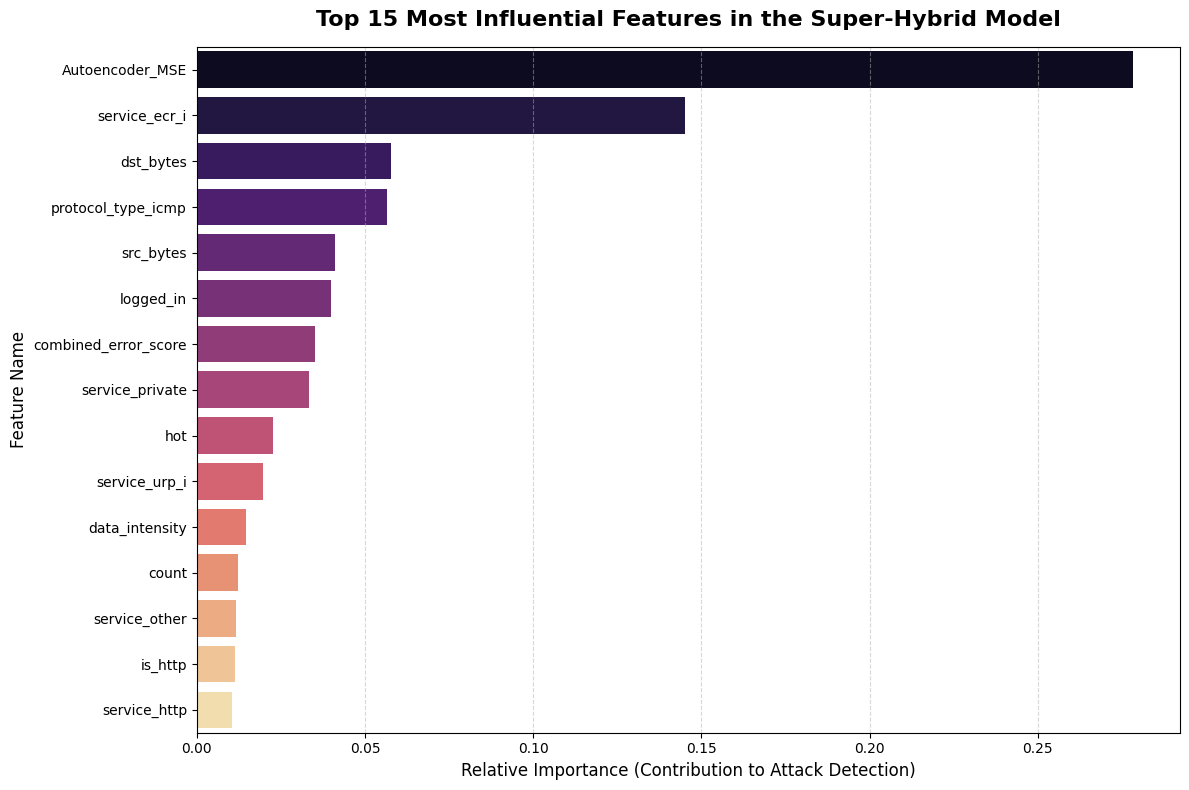

In [ ]:
# Cell 6: Explainable AI (Feature Importance Visualization)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Generating Feature Importance Plot...")

# 1. Reconstruct the exact feature names used during training
# We drop the targets and dummy-encode to match the X_train_clean structure
temp_df = train_df.drop(columns=['label', 'difficulty'], errors='ignore')
cat_cols = temp_df.select_dtypes(include=['object', 'string']).columns
base_features = pd.get_dummies(temp_df, columns=cat_cols).columns.tolist()

# 2. Add our custom Deep Learning and Anomaly features
# We appended MSE (1 feature) and Latent Features (16 features) to the array
all_feature_names = base_features + ['Autoencoder_MSE'] + [f'Deep_Latent_Feature_{i+1}' for i in range(16)]

# 3. Extract the 'Gini Importance' scores from our trained XGBoost
importances = xgb_super.feature_importances_
indices = np.argsort(importances)[::-1] # Sort from highest to lowest

# 4. Plot the Top 15 Most Important Features
plt.figure(figsize=(12, 8))
# Using a striking color palette for presentation contrast
sns.barplot(x=importances[indices[:15]], y=[all_feature_names[i] for i in indices[:15]], palette='magma')

plt.title('Top 15 Most Influential Features in the Super-Hybrid Model', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Relative Importance (Contribution to Attack Detection)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Save a small sample of your enriched test data for the dashboard
import pandas as pd

print("Exporting sample traffic for deployment...")
sample_indices = np.random.choice(len(X_test_super), 100, replace=False)

sample_data = pd.DataFrame(X_test_super[sample_indices])
sample_labels = pd.DataFrame(y_test[sample_indices], columns=['Actual_Label'])

sample_data.to_csv("sample_traffic.csv", index=False)
sample_labels.to_csv("sample_labels.csv", index=False)
print("✅ sample_traffic.csv and sample_labels.csv saved!")

Exporting sample traffic for deployment...
✅ sample_traffic.csv and sample_labels.csv saved!


In [ ]:
# Final Export Cell: Save Models and Sample Traffic (Fixed)
import joblib
import json
import pandas as pd
import numpy as np

print("Saving models and configurations for deployment...")

# 1. Save XGBoost
xgb_super.save_model("hybrid_xgb_model.json")
print("✅ XGBoost model saved.")

# 2. Save Autoencoder
autoencoder.save("deep_autoencoder.h5")
print("✅ Autoencoder model saved.")

# 3. Safely Reconstruct Feature Names for Config
temp_df = train_df.drop(columns=['label', 'difficulty'], errors='ignore')
cat_cols = temp_df.select_dtypes(include=['object', 'string']).columns
expected_encoded_cols = pd.get_dummies(temp_df, columns=cat_cols).columns.tolist()

# Save Config
deployment_config = {
    "anomaly_threshold": final_thresh,
    "expected_raw_columns": list(temp_df.columns),
    "expected_encoded_columns": expected_encoded_cols 
}

with open("deployment_config.json", "w") as f:
    json.dump(deployment_config, f)
print("✅ Configuration saved.")

# 4. Save Sample Traffic for the Dashboard
print("\nExporting sample traffic...")
sample_indices = np.random.choice(len(X_test_super), 100, replace=False)
sample_data = pd.DataFrame(X_test_super[sample_indices])
sample_labels = pd.DataFrame(y_test[sample_indices], columns=['Actual_Label'])

sample_data.to_csv("sample_traffic.csv", index=False)
sample_labels.to_csv("sample_labels.csv", index=False)
print("✅ sample_traffic.csv and sample_labels.csv saved!")

Saving models and configurations for deployment...
✅ XGBoost model saved.
✅ Autoencoder model saved.
✅ Configuration saved.

Exporting sample traffic...
✅ sample_traffic.csv and sample_labels.csv saved!


In [ ]:
# We need to recreate the column list after one-hot encoding but before scaling
X_temp = train_df.drop(columns=['label', 'difficulty'])
X_temp = pd.get_dummies(X_temp)

# Save these exact names to a CSV for your Streamlit app
pd.Series(X_temp.columns).to_csv('kdd_feature_names.csv', index=False, header=False)

print(f"Successfully saved {len(X_temp.columns)} feature names to kdd_feature_names.csv")

Successfully saved 129 feature names to kdd_feature_names.csv
